## Project 5 Python Code
This is the Python code deliverable. It will complete task #1 as defined in the SOW.\
Reference Volcanic-NRIDataDictionary.csv and the NRI website to understand data set.

#### Setup
Import data file and libraries.\
Format data as a data frame.

In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [2]:
#Setup data
nri_data = pd.read_csv('CIVE202_Spring2026_GroupINFRA-02-05_Project5_RawData.csv')
nri_data = pd.DataFrame(nri_data)
nri_data.head(1)

,Unnamed: 0,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,...,WFIR_EALT,WFIR_EALS,WFIR_EALR,WFIR_ALRB,WFIR_ALRP,WFIR_ALRA,WFIR_ALR_NPCTL,WFIR_RISKV,WFIR_RISKS,WFIR_RISKR
0,4200,4201,T06001400100,California,CA,6,Alameda,County,1,6001,...,83351.891118,94.186199,Relatively Moderate,0.000056,8.466201e-08,0.0,95.298063,90578.758052,94.00069,Relatively Moderate


#### State vs State Comparisons
Compare volcanic activity between the six states.
Potentially look at, numbers of events, frequency, types of annual loss, etc\
Look for geographical trends.

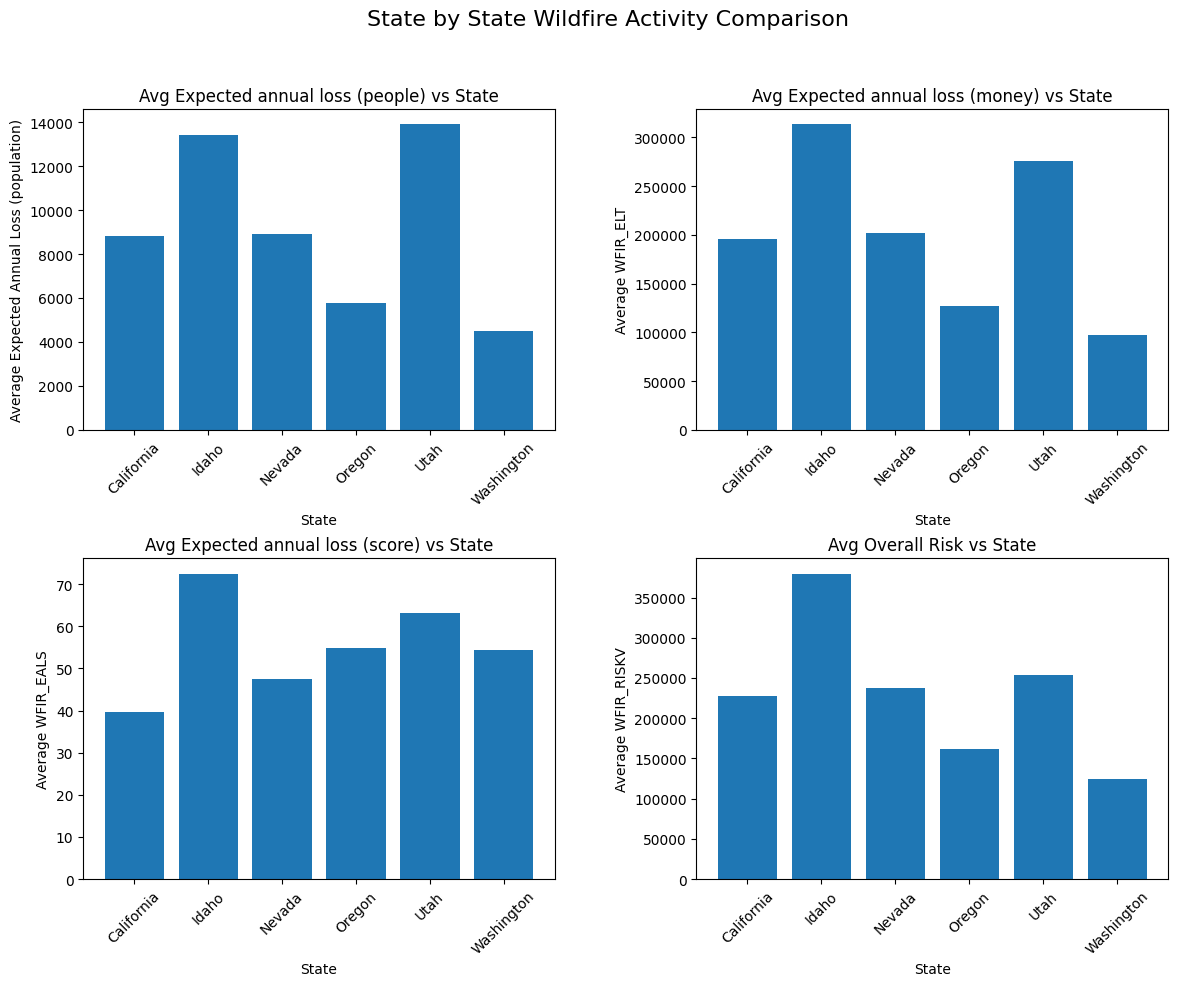

In [3]:
#Aggregate data

state_summary = nri_data.groupby("STATE").agg({
    "WFIR_EALPE" : "mean", # average expected annual loss (people affected)
    "WFIR_EALT":  "mean", # Expected annual loss - total(dollar) 
    "WFIR_EALS": "mean", #Expected annual loss score
    "WFIR_RISKV": "mean" # Overall Risk
    
}).reset_index()

#Graph or present in table
plt.figure(figsize = (14,10))
plt.suptitle("State by State Wildfire Activity Comparison", fontsize = 16)
## Avg Expected Annual Loss (population)
plt.subplot(2,2,1)
plt.bar(state_summary["STATE"], state_summary["WFIR_EALPE"])
plt.title("Avg Expected annual loss (people) vs State")
plt.xlabel("State")
plt.ylabel("Average Expected Annual Loss (population)")
plt.xticks(rotation=45)

##Avg expexted annual loss (dollar)
plt.subplot(2,2,2)
plt.bar(state_summary["STATE"], state_summary["WFIR_EALT"])
plt.title("Avg Expected annual loss (money) vs State")
plt.xlabel("State")
plt.ylabel("Average WFIR_ELT")
plt.xticks(rotation=45)

##Avg expected annual loss (score)
plt.subplot(2,2,3)
plt.bar(state_summary["STATE"], state_summary["WFIR_EALS"])
plt.title("Avg Expected annual loss (score) vs State")
plt.xlabel("State")
plt.ylabel("Average WFIR_EALS")
plt.xticks(rotation=45)

##Volcanic Risk Value
plt.subplot(2,2,4)
plt.bar(state_summary["STATE"], state_summary["WFIR_RISKV"])
plt.title("Avg Overall Risk vs State")
plt.xlabel("State")
plt.ylabel("Average WFIR_RISKV")
plt.xticks(rotation=45)

plt.subplots_adjust(hspace = 0.4, wspace = 0.3) #So the graphs don't overlap
plt.show()

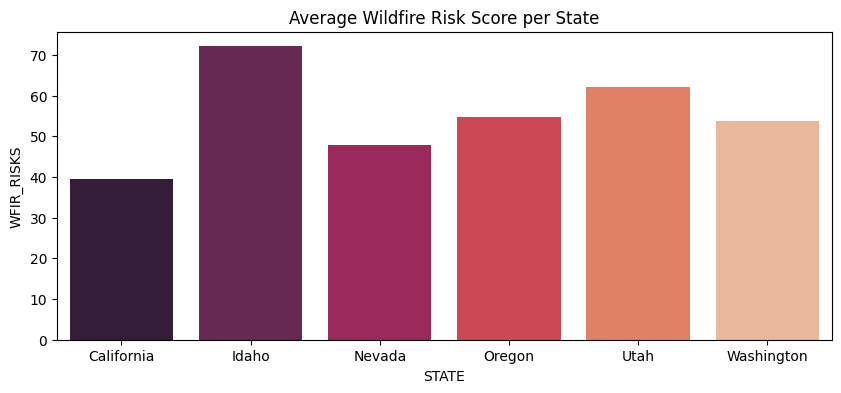

In [4]:
commun_risk_summary = nri_data.groupby("STATE").agg({
    "WFIR_RISKS" : "mean", # mean Wildfire risk value per state
}).reset_index()

#Graph in table
plt.figure(figsize = (10,4))
plt.title('Average Wildfire Risk Score per State')
sns.barplot(x=commun_risk_summary["STATE"], y=commun_risk_summary["WFIR_RISKS"], hue=commun_risk_summary["STATE"],  palette="rocket")
plt.show()

#### Population Impacts
NRI defines risk with the following:\
<span style="color:red">Risk</span> = <span style="color:orange">Expected Annual Loss</span> x Community Risk Factor\
&nbsp;&nbsp; - Community Risk Factor = (<span style="color:green">Social Vulnerability</span>/ <span style="color:purple">Community Resilience)</span>\
&nbsp;&nbsp; - <span style="color:orange">Expected Annual Loss</span> = Exposure x Annualized Frequency x Historical Loss Ratio\
\
Our Team will use the following definition of risk:\
<span style="color:red">Risk</span> = (<span style="color:blue">Annualized Frequency</span> x <span style="color:orange">Population Exposure</span>) x Community Risk Factor\
&nbsp;&nbsp; - Community Risk Factor = (<span style="color:green">Social Vulnerability</span>/ <span style="color:purple">Community Resilience)</span>\
\
\
Compare how the states do on the different risk definitions.

### Community Risk Factor
Both risk definitions use commuity risk in their calculations so lets look at how the states compare in this measurement.

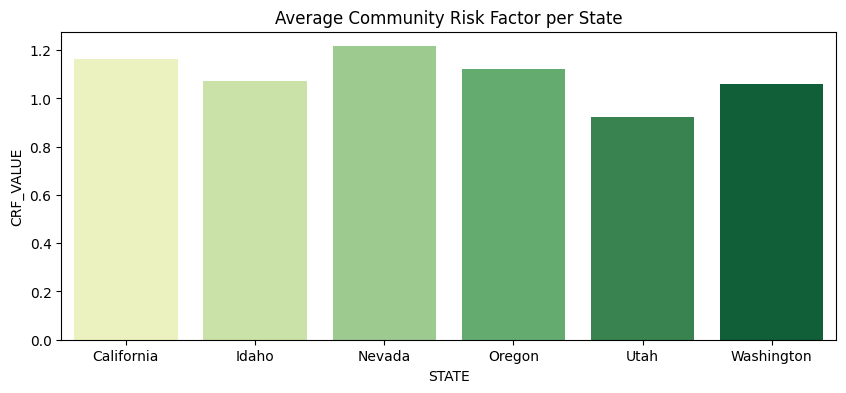

In [5]:
#Aggregate data
commun_risk_summary = nri_data.groupby("STATE").agg({
    "CRF_VALUE" : "mean", # mean community risk value per state
}).reset_index()

#Graph in table
plt.figure(figsize = (10,4))
plt.title('Average Community Risk Factor per State')
sns.barplot(x=commun_risk_summary["STATE"], y=commun_risk_summary["CRF_VALUE"], hue=commun_risk_summary["STATE"],  palette="YlGn")
plt.show()

### Risk Definition Comparisons
First need to add our definition as well as write a function to convert our risk value into a score out of 100.

Notice our `max_value` and `min_value` are the 90th and 1st percentiles respectively. This is to account for outliers.

In [15]:
def calculateCrScore(df):
    max_value = float(df['Custom_Risk_Value'].quantile(0.90))
    print(max_value)
    min_value = float(df['Custom_Risk_Value'].quantile(0.01))
    print(min_value)

    #convert value to scale of 0-100
    df['Custom_Risk_Score'] = ((df['Custom_Risk_Value'] - min_value)/(max_value-min_value))*100
    return df

In [19]:
#Add Risk Value
nri_data['Custom_Risk_Value'] = (nri_data['WFIR_AFREQ']*nri_data['WFIR_EXPP'])/nri_data['CRF_VALUE']

#Remove and 0 (null) values
nri_data= nri_data[nri_data['Custom_Risk_Value'] != 0]

#Calculate Score
nri_data = calculateCrScore(nri_data)

#Drop outliers
nri_data = nri_data[nri_data['Custom_Risk_Score'] <= 100]
nri_data = nri_data[nri_data['Custom_Risk_Score'] >= 0]

nri_data['Custom_Risk_Value'].head(10)

1.7437570486824703
0.0001179623106994677


0     1.253019
1     0.000669
19    0.001420
20    0.000209
35    0.003183
36    0.002989
37    0.003408
38    0.004553
42    0.008561
43    0.002543
Name: Custom_Risk_Value, dtype: float64

In [20]:
grouped_data = nri_data.groupby('STATE',as_index=False)
grouped_data = nri_data.groupby('STATE').agg(mean_nri_risk=('WFIR_RISKS','mean'),
                                                  mean_custom_risk=('Custom_Risk_Score','mean'))

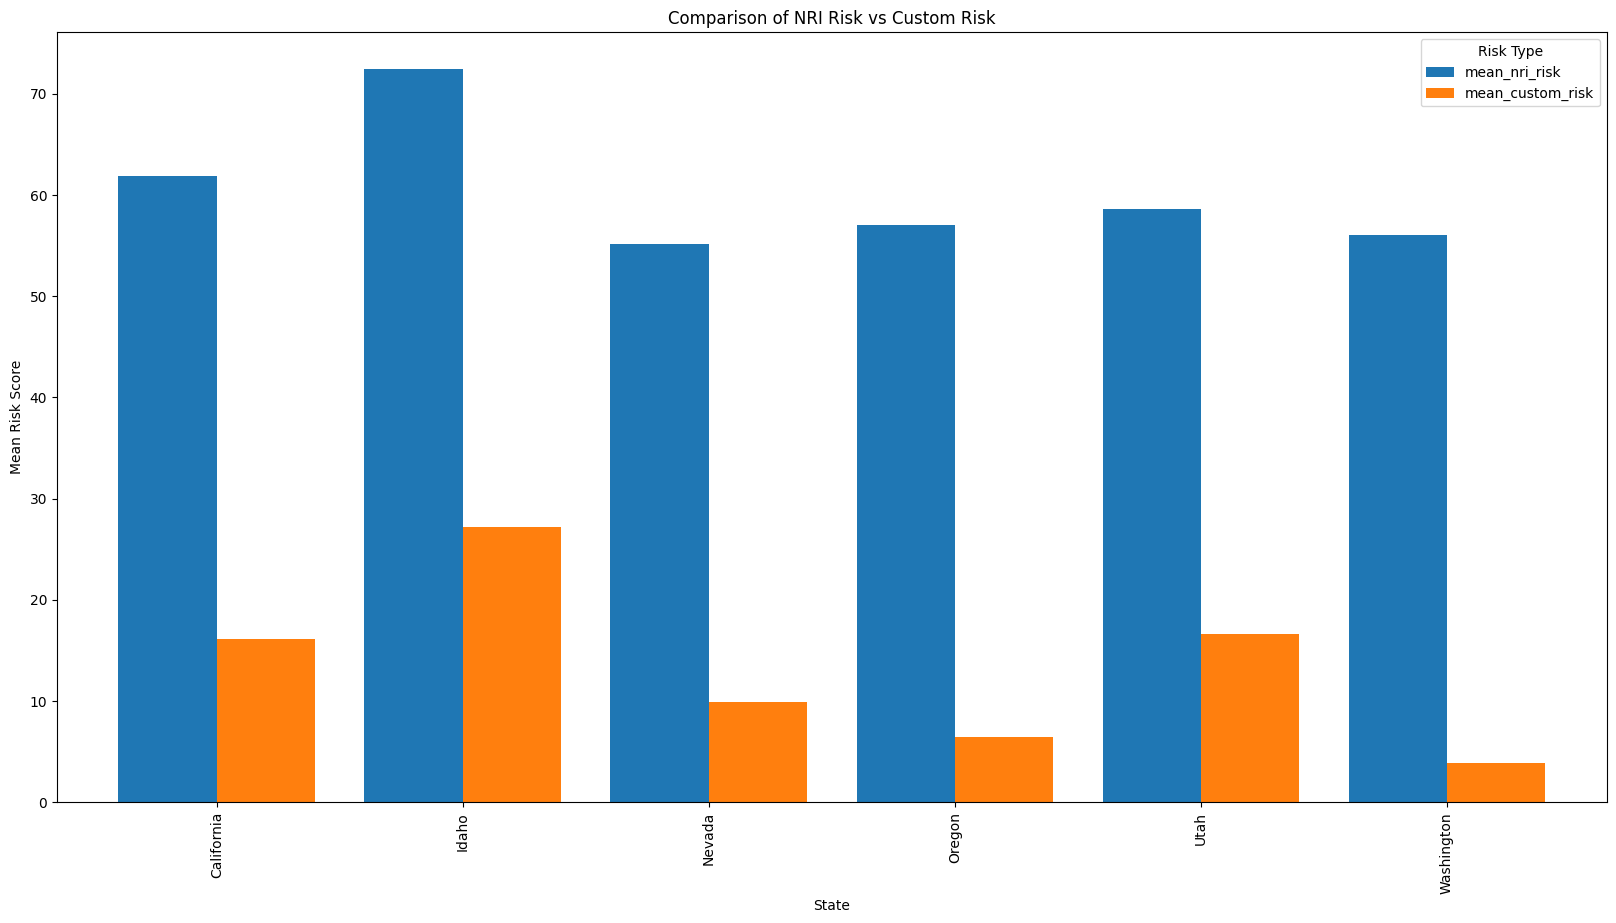

In [21]:
grouped_data.plot(kind='bar', figsize=(20,10), width=0.8)
plt.xlabel('State')
plt.ylabel('Mean Risk Score')
plt.title('Comparison of NRI Risk vs Custom Risk')
plt.xticks(rotation=90)
plt.legend(title="Risk Type")  # Adding a legend to distinguish risk types
plt.show()

## Geo Data Analysis

In [3]:
import geopandas as gpd
tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')

In [26]:
include = ['California', 'Idaho', 'Nevada', 'Oregon', 
           'Utan', 'Washington']

# Filter if your column is named 'STATE'
tracts_6states = tracts[tracts['STATE'].isin(include)]

In [27]:
#Add Risk Value
tracts_6states['Custom_Risk_Value'] = (tracts_6states['WFIR_AFREQ']*tracts_6states['WFIR_EXPP'])/tracts_6states['CRF_VALUE']

#Remove and 0 (null) values
tracts_6states= tracts_6states[tracts_6states['Custom_Risk_Value'] != 0]

#Calculate Score
tracts_6states = calculateCrScore(tracts_6states)

#Drop outliers
tracts_6states = tracts_6states[tracts_6states['Custom_Risk_Score'] <= 100]
tracts_6states = tracts_6states[tracts_6states['Custom_Risk_Score'] >= 0]

tracts_6states['Custom_Risk_Score'].head(5)

12.860825830770112
2.3220153047115127e-05


C:\Users\willm\AppData\Local\Programs\Python\Python313\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


4200    5.005503
4219    0.007829
4220    0.001510
4230    0.000293
4235    0.022101
Name: Custom_Risk_Score, dtype: float64

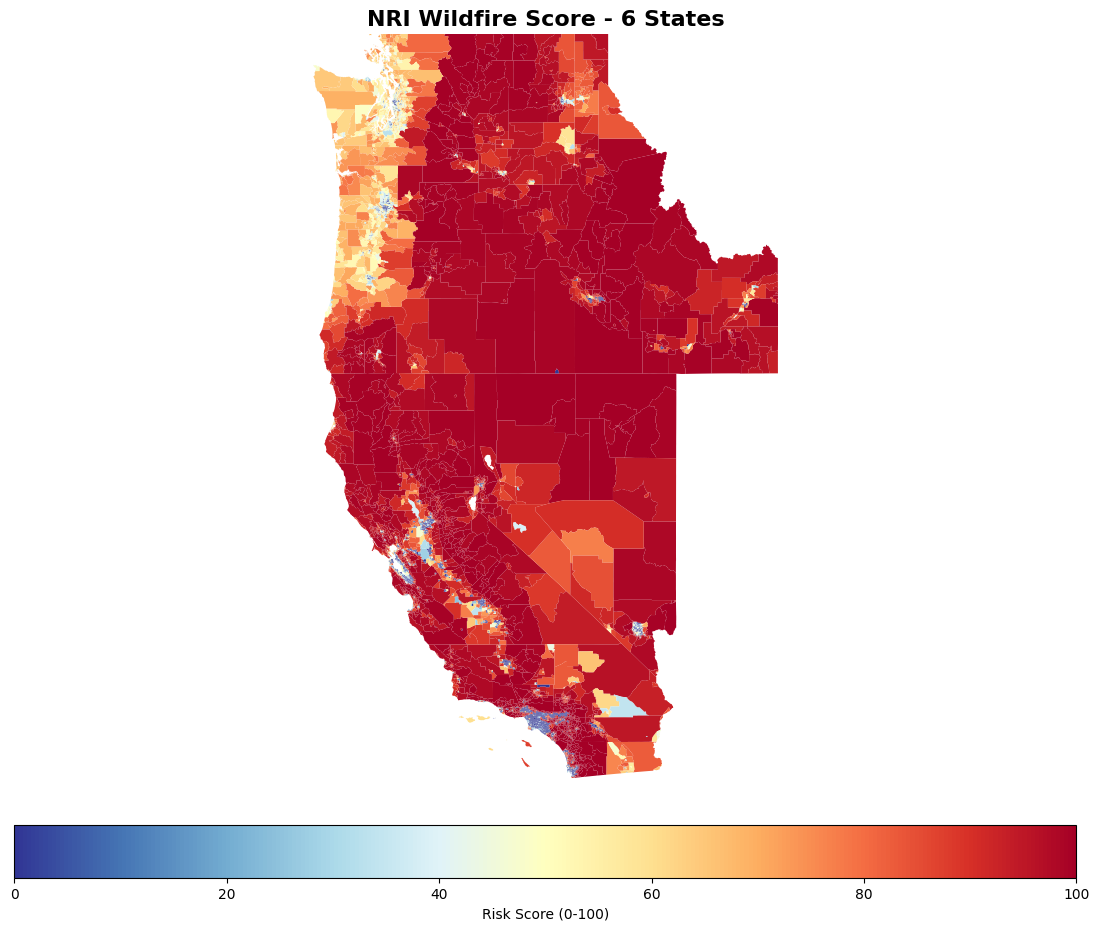

In [9]:
fig, ax = plt.subplots(1,1, figsize=(18,10))
tracts_6states.plot(
    column="WFIR_RISKS", 
    cmap="RdYlBu_r", 
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds={"color": "lightgrey", "label": "No Data"})

minx, miny, maxx, maxy = tracts_6states.total_bounds
padding = 0.5
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)

ax.set_title("NRI Wildfire Score - 6 States", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

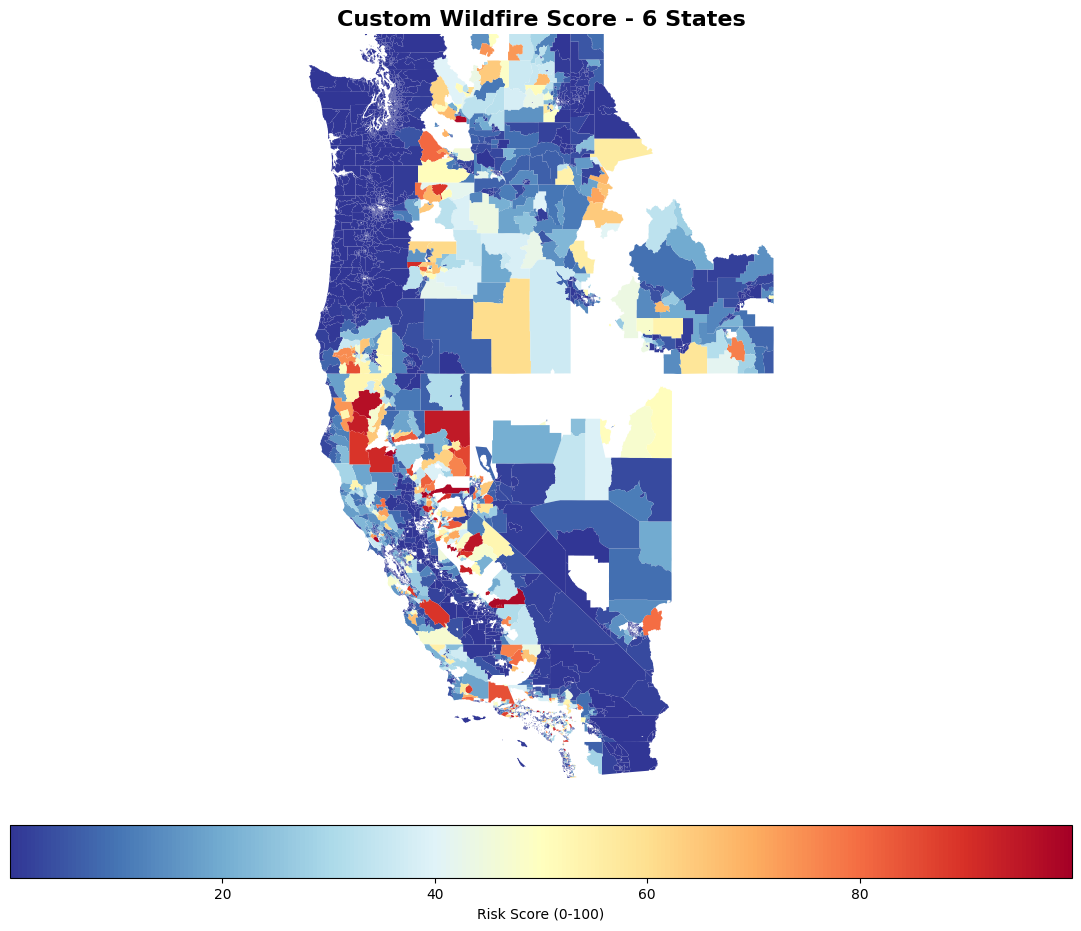

In [28]:
fig, ax = plt.subplots(1,1, figsize=(18,10))
tracts_6states.plot(
    column="Custom_Risk_Score", 
    cmap="RdYlBu_r", 
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds={"color": "grey", "label": "No Data"})

minx, miny, maxx, maxy = tracts_6states.total_bounds
padding = 0.5
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)

ax.set_title("Custom Wildfire Score - 6 States", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()